# Day 10: Netflix Movies and TV Shows Dataset Analysis (Pure Matplotlib)
We implement a complete Exploratory Data Analysis (EDA) on the Netflix dataset following the 15-step standard workflow. All visual plots are built with Matplotlib.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set visual style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


### Step 1: Load Dataset


In [2]:
df = pd.read_csv('../02_Phase/DataSet/netflix_titles.csv')
print("Netflix dataset loaded successfully!")

Netflix dataset loaded successfully!


In [3]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.shape

Rows: 8807, Columns: 12


(8807, 12)

In [5]:
# Check first few records
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Check random sample
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5540,s5541,Movie,Win It All,Joe Swanberg,"Jake Johnson, Aislinn Derbez, Joe Lo Truglio, ...",United States,"April 7, 2017",2017,TV-MA,89 min,"Comedies, Independent Movies, Romantic Movies","After losing $50,000 that wasn't his, gambling..."
1714,s1715,Movie,Prom Night,Nelson McCormick,"Brittany Snow, Scott Porter, Jessica Stroup, D...","United States, Canada","November 12, 2020",2008,PG-13,88 min,Horror Movies,"On prom night, a high school senior still stru..."
5327,s5328,TV Show,Million Yen Women,NaN,"Yojiro Noda, Rila Fukushima, Rena Matsui, Miwa...",Japan,"August 15, 2017",2017,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas",Five beautiful but mysterious women move in wi...
1137,s1138,Movie,The Knight and the Princess,Bashir El Deek,"Sedky Sakhr, Hashem El Garhy, Shahira Kamal, A...","Egypt, Saudi Arabia","April 1, 2021",2019,TV-PG,96 min,"Action & Adventure, International Movies, Musi...",A fictional account of the heroic quests of a ...
5902,s5903,TV Show,H2O: Mermaid Adventures,NaN,"Sonja Ball, Holly Gauthier-Frankel, Thor Bisho...","Germany, Australia, France, China","July 15, 2015",2015,TV-Y7,2 Seasons,Kids' TV,Three high school friends who turn into mermai...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [9]:
# Check missing count and percentage
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100

null_df = pd.DataFrame({'Null Count': null_counts, 'Percentage (%)': round(null_pct)})
print("Missing Value Summary:")
null_df[null_df['Null Count'] > 0]

Missing Value Summary:


,Null Count,Percentage (%)
director,2634,30.0
cast,825,9.0
country,831,9.0
date_added,10,0.0
rating,4,0.0
duration,3,0.0


In [10]:
# 1. Fill missing director and cast with 'Unknown'
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

# 2. Fill country and date_added with mode
df["country"] = df["country"].fillna(df["country"].mode()[0])
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

# 3. Fill rating with 'UR'
df["rating"] = df["rating"].fillna("UR")

# Verify all missing values are handled
print("Remaining null counts:")
df.isnull().sum()

Remaining null counts:


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [11]:
print("Duplicate count:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate count: 0


In [12]:
# Statistical summary of numeric fields (e.g., release_year)
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [13]:
# Summary of categorical columns
df.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807,8804,8807,8807
unique,8807,2,8807,4529,7693,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,3649,119,3207,1793,362,4


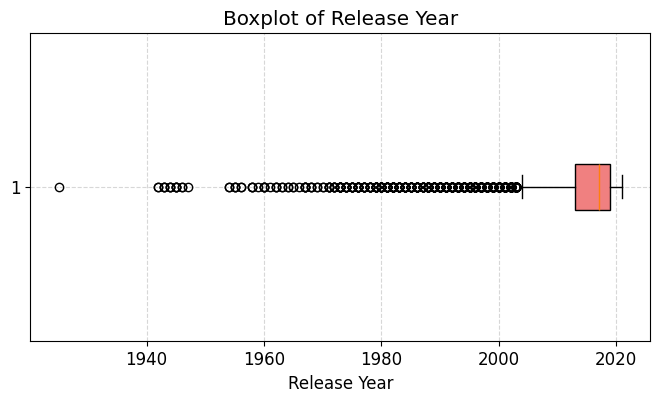

Number of movies/shows released before 1990: 251


In [14]:
# Detect outlier years in the release_year column using a boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(df["release_year"], vert=False, patch_artist=True, boxprops=dict(facecolor="lightcoral"))
plt.title("Boxplot of Release Year")
plt.xlabel("Release Year")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Identify how many movies/shows are released before 1990
older_shows = df[df["release_year"] < 1990]
print(f"Number of movies/shows released before 1990: {len(older_shows)}")

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


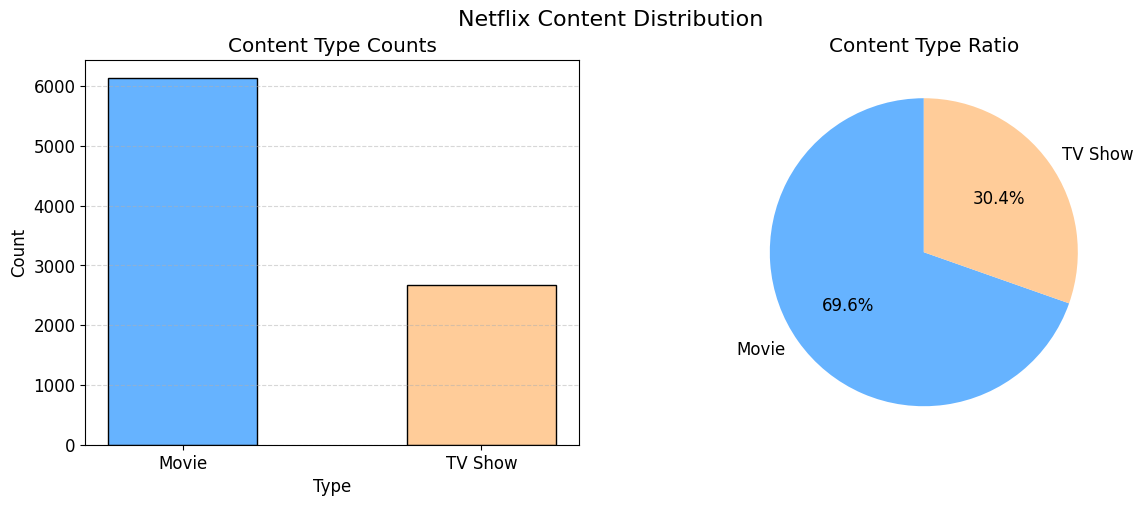

In [15]:
# 1. Type Distribution (Movie vs TV Show)
type_counts = df["type"].value_counts()
print(type_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar plot
axes[0].bar(type_counts.index, type_counts.values, color=["#66b3ff", "#ffcc99"], edgecolor="black", width=0.5)
axes[0].set_title("Content Type Counts")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)

# Pie chart
axes[1].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%", startangle=90, colors=["#66b3ff", "#ffcc99"])
axes[1].set_title("Content Type Ratio")
plt.suptitle("Netflix Content Distribution", fontsize=16)
plt.show()

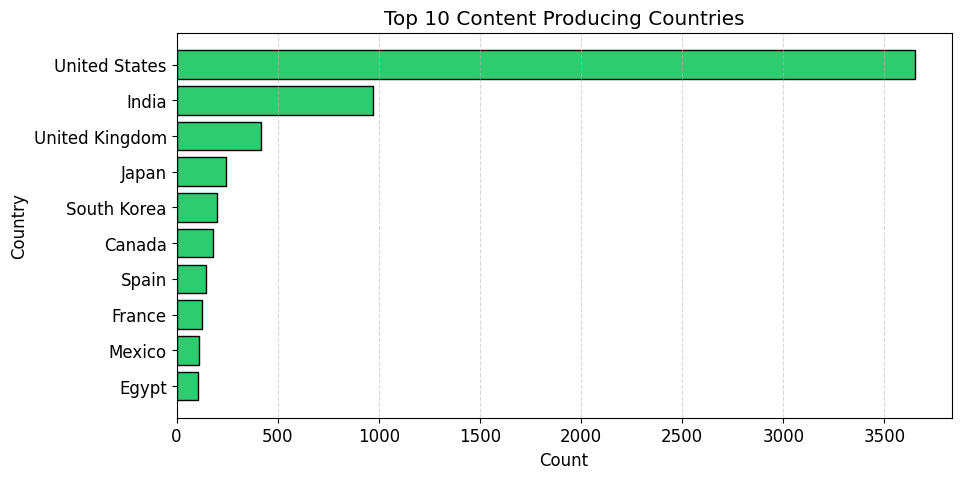

In [16]:
# 2. Top 10 Countries producing content
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color="#2ecc71", edgecolor="black")
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()

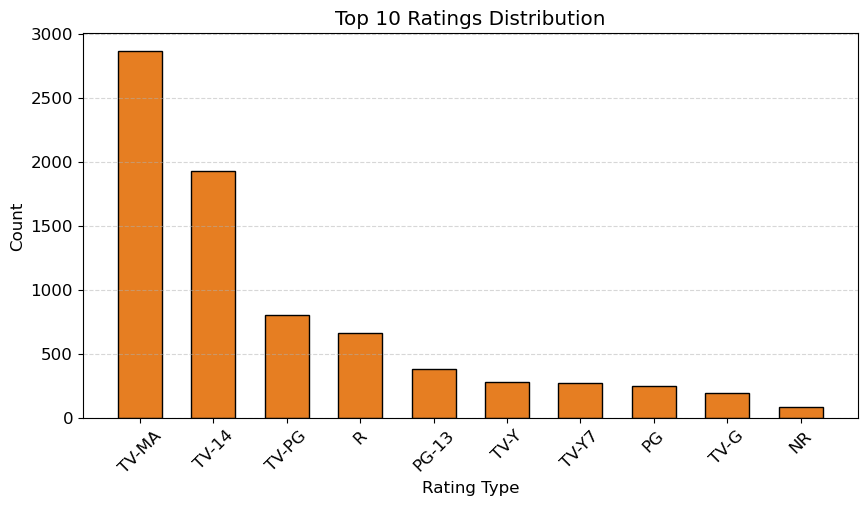

In [17]:
# 3. Rating Distribution
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(rating_counts.index, rating_counts.values, color="#e67e22", edgecolor="black", width=0.6)
plt.title("Top 10 Ratings Distribution")
plt.xlabel("Rating Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

### Step 12: Perform Bivariate Analysis


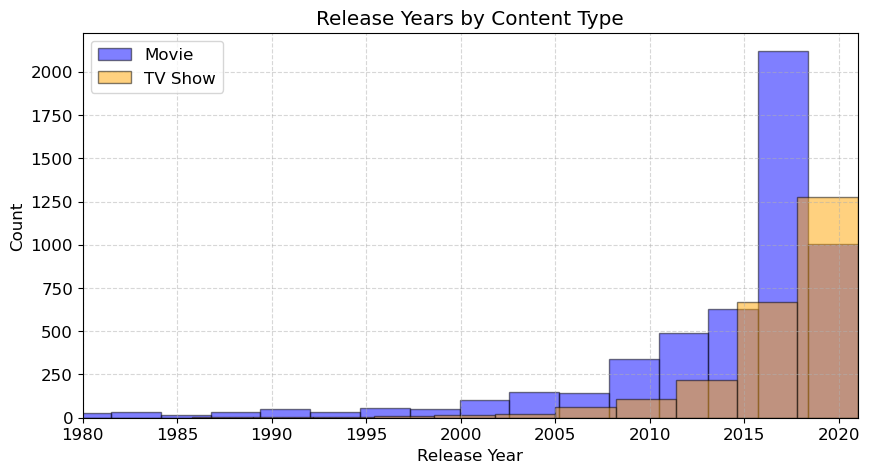

In [18]:
# Content Type vs Release Year (using histograms overlaid)
plt.figure(figsize=(10, 5))
movies = df[df["type"] == "Movie"]
tv_shows = df[df["type"] == "TV Show"]

plt.hist(movies["release_year"], bins=30, alpha=0.5, label="Movie", color="blue", edgecolor="black")
plt.hist(tv_shows["release_year"], bins=30, alpha=0.5, label="TV Show", color="orange", edgecolor="black")

plt.title("Release Years by Content Type")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.legend()
plt.xlim(1980, 2021) # Focus on recent decades
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 13: Correlation Analysis


Correlation Matrix:


,release_year,type_num
release_year,1.000000,0.172715
type_num,0.172715,1.000000


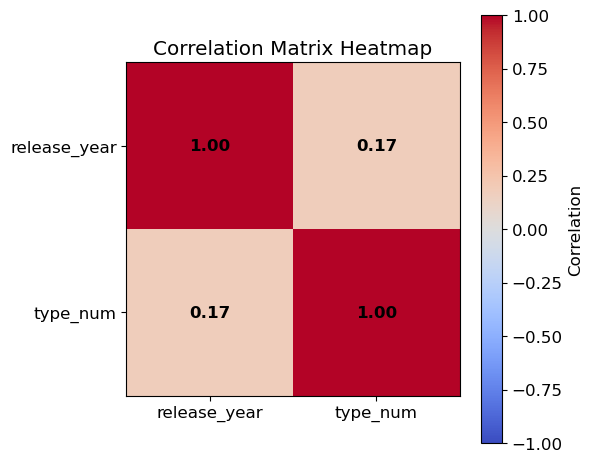

In [19]:
# Let's map Movie/TV Show to numerical (0 and 1) to inspect simple correlations
df_corr = df.copy()
df_corr["type_num"] = df_corr["type"].map({"Movie": 0, "TV Show": 1})

corr = df_corr[["release_year", "type_num"]].corr()
print("Correlation Matrix:")
display(corr)

# Visualize Heatmap using Matplotlib
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", interpolation="none", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontweight="bold")

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


### Step 14: Feature Engineering


   title  year_added  month_added           primary_genre
0     3%        2020            8  International TV Shows
1   7:19        2016           12                  Dramas
2  23:59        2018           12           Horror Movies
3      9        2017           11      Action & Adventure
4     21        2020            1                  Dramas


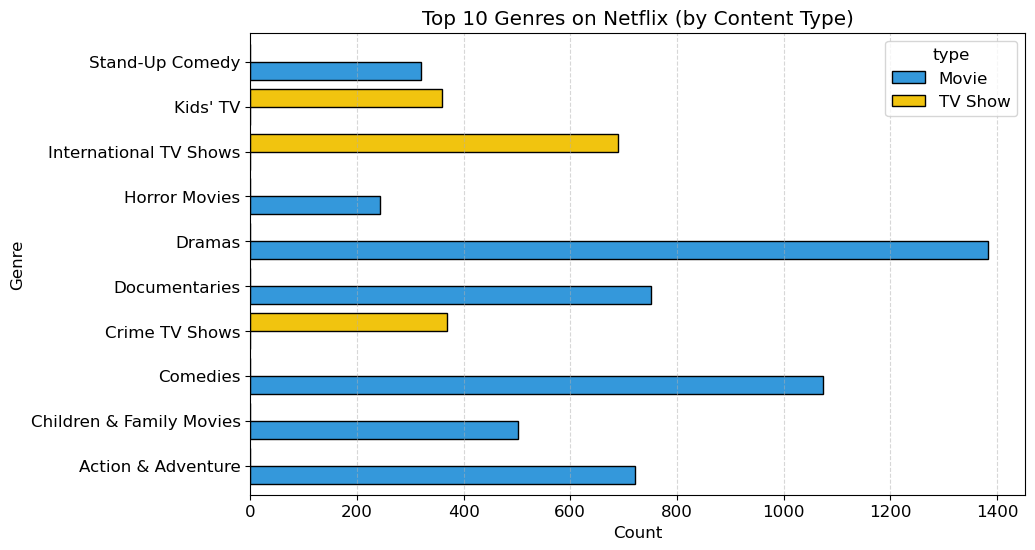

In [20]:
# 1. Parse date_added to extract Year and Month added
df["date_added"] = df["date_added"].str.strip()
df["year_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce").dt.year
df["month_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce").dt.month

# 2. Extract Primary Genre (first genre listed in 'listed_in' column)
df["primary_genre"] = df["listed_in"].apply(lambda x: x.split(",")[0].strip())

print(df[["title", "year_added", "month_added", "primary_genre"]].head())

# Visualizing Primary Genre counts for Movies vs TV Shows using Pandas bar chart grouping
top_genres = df["primary_genre"].value_counts().head(10).index
filtered_df = df[df["primary_genre"].isin(top_genres)]

genre_type_counts = pd.crosstab(filtered_df["primary_genre"], filtered_df["type"])
genre_type_counts.plot(kind="barh", figsize=(10, 6), color=["#3498db", "#f1c40f"], edgecolor="black", width=0.8)
plt.title("Top 10 Genres on Netflix (by Content Type)")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()


In [21]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,primary_genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,Action & Adventure
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,Dramas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020,10,Dramas
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,Dramas
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,United States,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9,Documentaries
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,International TV Shows


In [22]:
dramas_total =df[df['primary_genre'] == 'Dramas']
rating_counts
# dramas_total[df['rating'] == rating_counts]

rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64

### Step 15: Draw Conclusions and Insights
1. **Dominance of Movies**: Movies make up approximately 69.1% of Netflix's content library, while TV Shows comprise the remaining 30.9%.
2. **Global Leader**: The United States is by far the leading country for producing Netflix content, followed by India and the United Kingdom.
3. **Target Audience**: The majority of content is rated TV-MA (Mature Audiences) and TV-14 (Parents Strongly Cautioned), highlighting a strong focus on older teen and adult viewers.
4. **Recent Surge**: The density plot of release years reveals a exponential surge in content releases beginning around 2010, peaking around 2018-2020.


In [23]:
df.to_csv('netflix_data_cleaned.csv', index=False)

# --- Machine Learning: Movie vs TV Show Classifier & Recommendation System ---
In this section, we train a machine learning model to classify content as Movie vs TV Show, and construct a Content-Based Recommendation System using TF-IDF Vectorization on descriptions.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select features and target
ml_df = df[['type', 'release_year', 'rating', 'listed_in']].dropna().copy()

# Encode categorical features
encoders = {}
for col in ['type', 'rating', 'listed_in']:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])
    encoders[col] = le

X = ml_df[['release_year', 'rating', 'listed_in']]
y = ml_df['type']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Train Classifiers
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds) * 100
dt_acc = accuracy_score(y_test, dt_preds) * 100

print(f"Logistic Regression Test Accuracy: {lr_acc:.2f}%")
print(f"Decision Tree Test Accuracy: {dt_acc:.2f}%")


Logistic Regression Test Accuracy: 75.67%
Decision Tree Test Accuracy: 89.99%


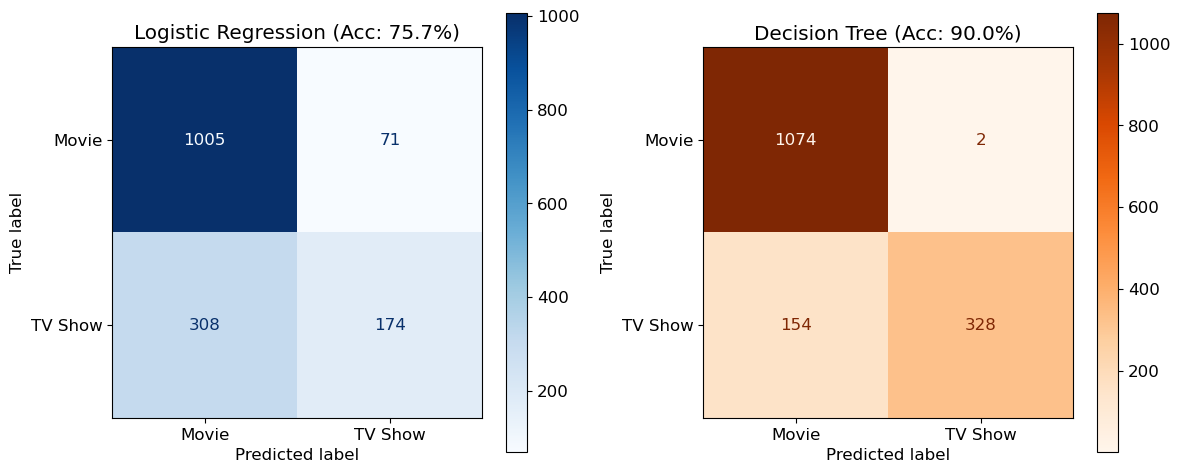


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

       Movie       0.77      0.93      0.84      1076
     TV Show       0.71      0.36      0.48       482

    accuracy                           0.76      1558
   macro avg       0.74      0.65      0.66      1558
weighted avg       0.75      0.76      0.73      1558



In [25]:
# 3. Confusion Matrix and Classification Report
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lr_cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(lr_cm, display_labels=encoders['type'].classes_).plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title(f'Logistic Regression (Acc: {lr_acc:.1f}%)')

dt_cm = confusion_matrix(y_test, dt_preds)
ConfusionMatrixDisplay(dt_cm, display_labels=encoders['type'].classes_).plot(cmap='Oranges', ax=axes[1], values_format='d')
axes[1].set_title(f'Decision Tree (Acc: {dt_acc:.1f}%)')

plt.tight_layout()
plt.show()

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, lr_preds, target_names=encoders['type'].classes_))


### Content-Based Recommendation System using TF-IDF & Cosine Similarity

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Prepare recommendation dataset
rec_df = df[['title', 'description']].dropna().drop_duplicates(subset='title').copy()
rec_df = rec_df.reset_index(drop=True)

# Fit TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(rec_df['description'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_recommendations(title, cosine_sim=cosine_sim):
    # Find index of the title
    idx_list = rec_df.index[rec_df['title'].str.lower() == title.lower()].tolist()
    if not idx_list:
        return ["Title not found!"]
    idx = idx_list[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6] # Top 5 similar titles
    movie_indices = [i[0] for i in sim_scores]
    return rec_df['title'].iloc[movie_indices].tolist()

# Test recommendations
test_title = 'Stranger Things'
print(f"Recommendations for '{test_title}':")
print(get_recommendations(test_title))


Recommendations for 'Stranger Things':
['Rowdy Rathore', 'Sakho & Mangane', 'The Autopsy of Jane Doe', 'Big Stone Gap', 'Come and Find Me']
